{'domain': {'x_bounds': [1000, 1000], 'y_bounds': [1000, 1000], 'n_cells': [50, 50]}, 'survey': {'x_spacing': 80, 'x_bounds': [-200, 200], 'y_spacing': 20, 'y_bounds': [-200, 200], 'z_height': 10, 'components': ['tmi']}, 'inducing_field': {'inclination': 90, 'declination': 0, 'amplitude': 50000}, 'mesh': {'dx': 20, 'dy': 20, 'dz': 20, 'x_length': 4000, 'y_length': 4000, 'z_length': 2000}, 'model': {'background_susceptibility': 0.1, 'curie_depth': 1000, 'curie_susceptibility': 0.05}}


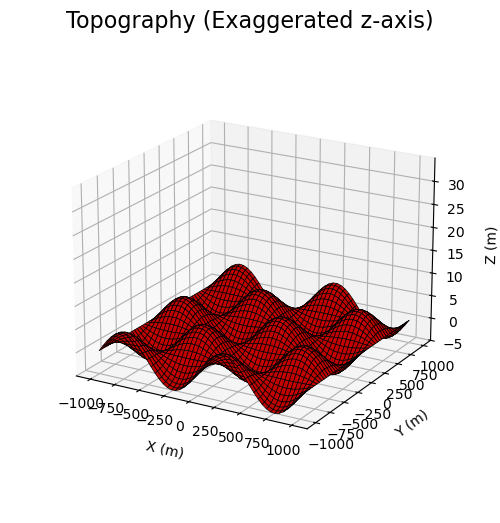

In [1]:
from forward_simulation import ForwardSimulation
from matplotlib import pyplot as plt
import numpy as np
import matplotlib as mpl
from discretize.utils import mkvc
from simpeg.utils import plot2Ddata
from simpeg import maps
from simpeg.potential_fields import magnetics

def z_func(x, y):
    return 5*np.sin(2 * np.pi * x / 1000) * np.cos(2 * np.pi * y / 1000)

simulation = ForwardSimulation(
    "forward_model_params.yml",
    z_func=z_func,
    randomize_model=True,
)


fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([simulation.z_topo.max() -10, simulation.z_topo.max()+30])
ax.plot_surface(simulation.x_topo, simulation.y_topo, simulation.z_topo, color="r", edgecolor="k", linewidth=0.5)
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=20.0)

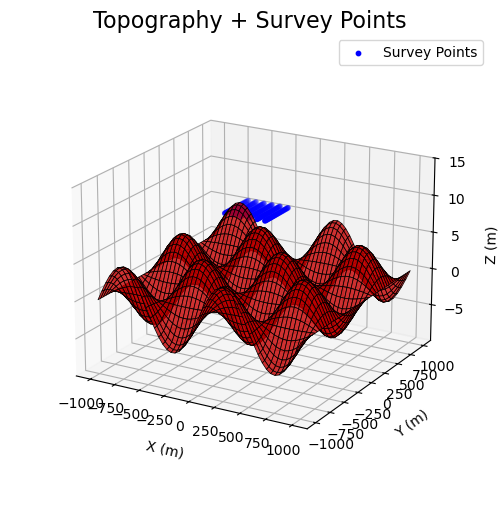

In [2]:
# Visualize survey points on a fresh figure so this cell always renders output
fig2 = plt.figure(figsize=(6, 6))
ax2 = fig2.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")

# Re-plot topography
ax2.plot_surface(
    simulation.x_topo, simulation.y_topo, simulation.z_topo,
    color="r", edgecolor="k", linewidth=0.5, alpha=0.8
)


X_survey, Y_survey = np.meshgrid(simulation.x_survey, simulation.y_survey)
ax2.scatter(X_survey.ravel(), Y_survey.ravel(), simulation.z_survey.ravel(), color="b", s=10, label="Survey Points")

# Keep z-range including both topography and survey points
zmin = simulation.z_topo.min() - 5
zmax = max(simulation.z_topo.max(), simulation.z_survey.max()) + 5
ax2.set_zlim([zmin, zmax])

ax2.set_box_aspect(aspect=None, zoom=0.85)
ax2.set_xlabel("X (m)", labelpad=10)
ax2.set_ylabel("Y (m)", labelpad=10)
ax2.set_zlabel("Z (m)", labelpad=10)
ax2.set_title("Topography + Survey Points", fontsize=16, pad=-20)
ax2.view_init(elev=20.0)
ax2.legend(loc="upper right")
plt.show()

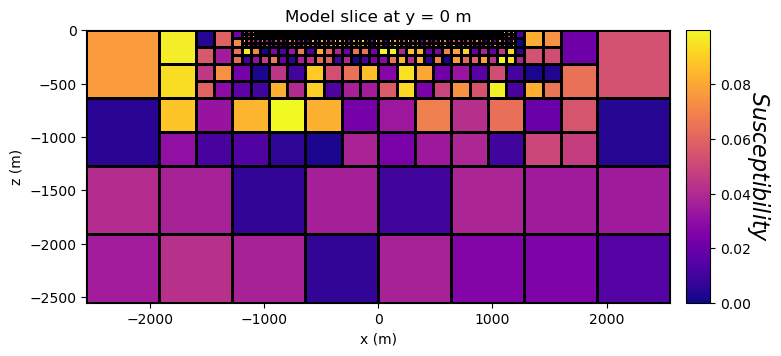

In [3]:
fig = plt.figure(figsize=(8, 3.5))
ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.78])
plotting_map = maps.InjectActiveCells(simulation.mesh, simulation.active_cells, np.nan)

norm = mpl.colors.Normalize(vmin=0, vmax=np.max(simulation.model))
simulation.mesh.plot_slice(
    plotting_map * simulation.model,
    normal="Y",
    ax=ax1,
    ind=int(simulation.mesh.shape_cells[1] / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.85, 0.12, 0.03, 0.78])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$Susceptibility$", rotation=270, labelpad=15, size=16)

plt.show()

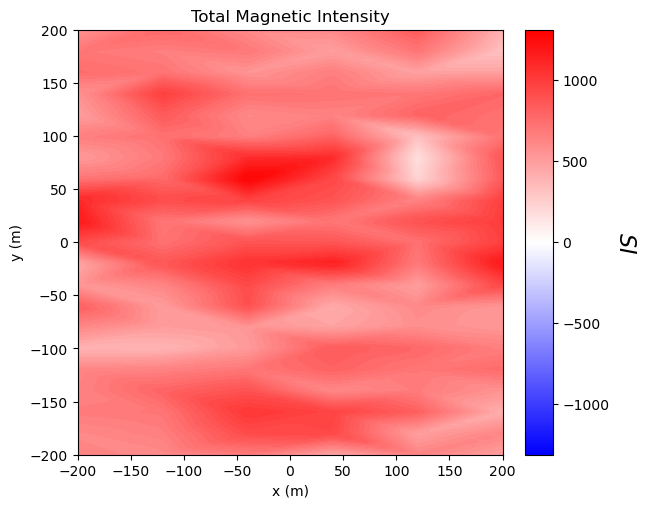

In [4]:
#view the forward simulation results
fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85])
x_grid, y_grid = np.meshgrid(simulation.x_survey, simulation.y_survey)
locations = np.c_[mkvc(x_grid), mkvc(y_grid), mkvc(simulation.z_survey)]

# Use the observation locations and components to define the receivers. To
# simulate data, the receivers must be defined as a list.
receiver_list = magnetics.receivers.Point(locations, components=["tmi"])
receiver_list = [receiver_list]

norm = mpl.colors.Normalize(vmin=-np.max(np.abs(simulation.dpred)), vmax=np.max(np.abs(simulation.dpred)))
plot2Ddata(
    receiver_list[0].locations,
    simulation.dpred,
    ax=ax1,
    ncontour=40,
    contourOpts={"cmap": mpl.cm.bwr, "norm": norm},
)
ax1.set_title("Total Magnetic Intensity")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

ax2 = fig.add_axes([0.81, 0.1, 0.04, 0.85])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr
)
cbar.set_label("$SI$", rotation=270, labelpad=20, size=16)

plt.show()